In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Makes charts look clean
sns.set_theme(style="darkgrid")
print("Libraries loaded!")

Libraries loaded!


In [2]:
# Pick your stocks — feel free to change these!
tickers = ["AAPL", "TSLA", "MSFT"]

# Download 2 years of daily price data
data = yf.download(tickers, start="2022-01-01", end="2024-01-01")

# We only need the 'Close' price (price at end of each day)
close_prices = data["Close"]

print(close_prices.head())  # Preview the first few rows

[*********************100%***********************]  3 of 3 completed

Ticker            AAPL        MSFT        TSLA
Date                                          
2022-01-03  178.103668  323.160828  399.926666
2022-01-04  175.843231  317.619568  383.196655
2022-01-05  171.165848  305.426758  362.706665
2022-01-06  168.308502  303.013336  354.899994
2022-01-07  168.474869  303.167847  342.320007


In [8]:
# Save the data to a CSV file in the data folder
close_prices.to_csv("../data/stock_prices.csv")
print("Data saved to data/stock_prices.csv!")

Data saved to data/stock_prices.csv!


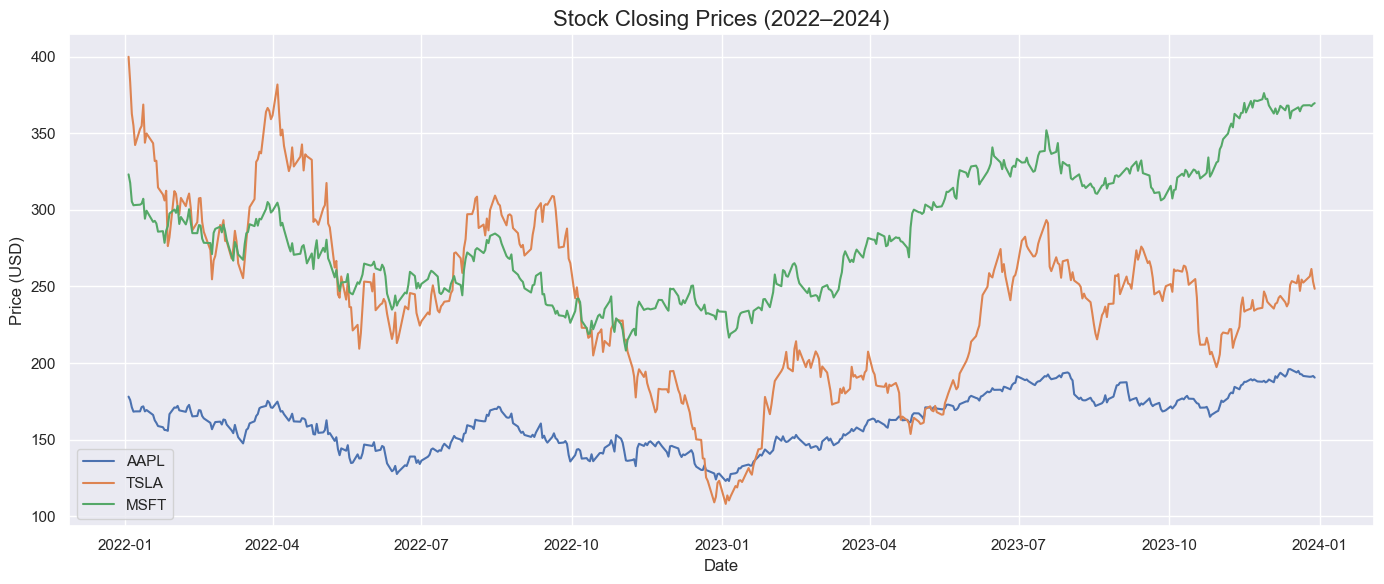

In [3]:
plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(close_prices[ticker], label=ticker)

plt.title("Stock Closing Prices (2022–2024)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../images/stock_prices.png")  # Save the chart
plt.show()

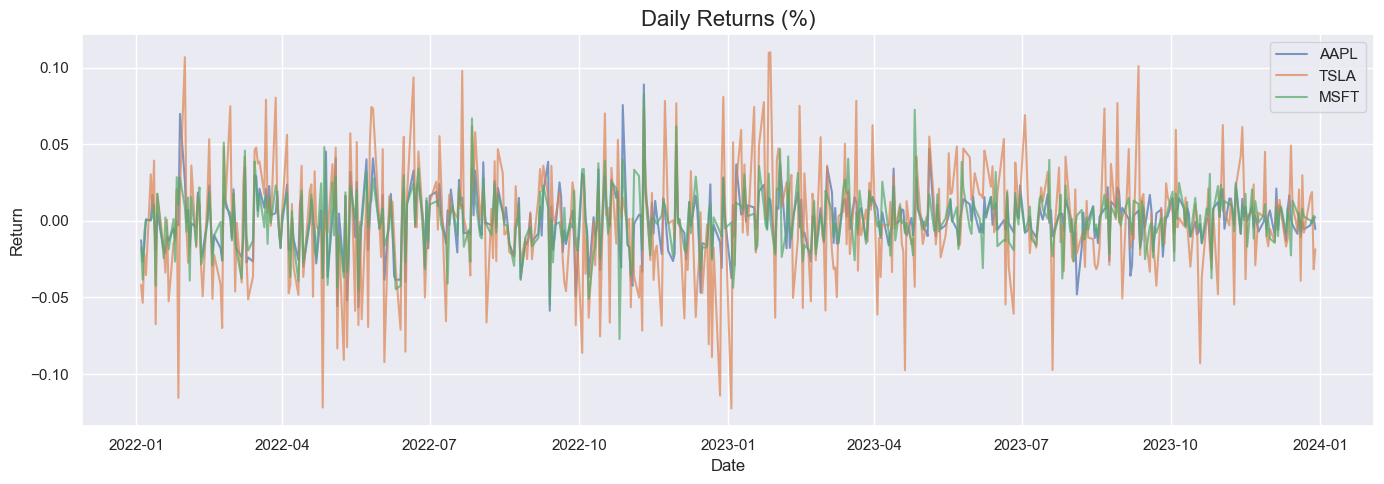

In [4]:
# Percentage change day-over-day
daily_returns = close_prices.pct_change().dropna()

plt.figure(figsize=(14, 5))
for ticker in tickers:
    plt.plot(daily_returns[ticker], label=ticker, alpha=0.7)

plt.title("Daily Returns (%)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.savefig("../images/daily_returns.png")
plt.show()

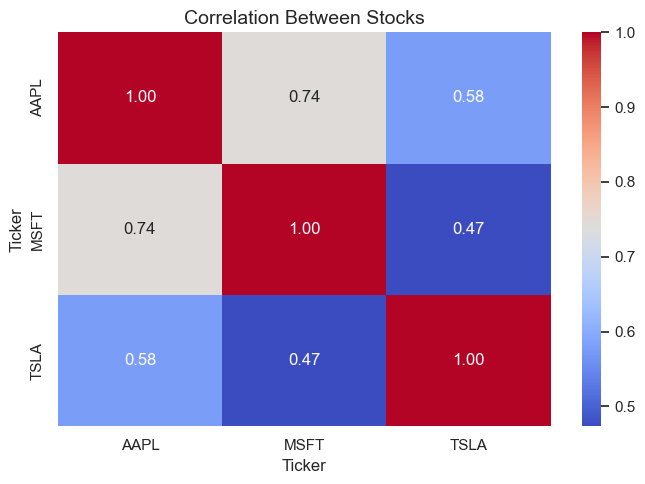

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(daily_returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Stocks", fontsize=14)
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png")
plt.show()

In [6]:
print("=== Summary Statistics ===")
print(close_prices.describe().round(2))

print("\n=== Average Daily Return ===")
print(daily_returns.mean().round(4))

print("\n=== Risk (Volatility = Std Dev of Returns) ===")
print(daily_returns.std().round(4))

=== Summary Statistics ===
Ticker    AAPL    MSFT    TSLA
count   501.00  501.00  501.00
mean    161.13  284.02  240.33
std      17.73   40.91   55.39
min     123.05  208.18  108.10
25%     146.78  248.61  197.37
50%     162.04  278.54  241.87
75%     174.04  318.43  276.04
max     196.07  376.22  399.93

=== Average Daily Return ===
Ticker
AAPL    0.0003
MSFT    0.0005
TSLA   -0.0002
dtype: float64

=== Risk (Volatility = Std Dev of Returns) ===
Ticker
AAPL    0.0183
MSFT    0.0194
TSLA    0.0379
dtype: float64
